# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

# leer conjuntos de datos en los DataFrames
df_orders = pd.read_csv('instacart_orders.csv', sep= ';') 
df_products = pd.read_csv('products.csv', sep= ';')
df_aisles = pd.read_csv('aisles.csv', sep= ';')
df_departments = pd.read_csv('departments.csv', sep= ';')
df_order_products= pd.read_csv('order_products.csv', sep= ';')


In [3]:
# mostrar información del DataFrame
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [4]:
# mostrar información del DataFrame
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [5]:
# mostrar información del DataFrame
df_aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [6]:
# mostrar información del DataFrame
df_departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


In [7]:
# mostrar información del DataFrame
df_order_products.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.

- para df_orders se observan 6 colomnas, 28819 datos nulos y dos tipos de datos int64 y float
- para df_products se observa 4 columnas, 1258 datos nulos y dos tipos de datos int64 y object.
- para df_aisles se observa 2 columnas y 2 tipos de datos int54 y object.
- para df_departments se observa 2 colmunas y dos tipos de datos int54 y object.
- para df_order_products se observa 4 columnas 836 datos nulos y dos tipos de datos int64 y float.



# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [8]:
# Revisa si hay pedidos duplicados
print(df_orders.duplicated().sum())


15


In [9]:
df_orders_clean= df_orders[df_orders.duplicated()]

In [10]:

df_orders_clean

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

Si hay lineas duplicadas y tienen en comun el día Miercoles a las 2:00 de la mañana el dia que se realizo el pedido.

In [11]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
df_orders.query("order_hour_of_day==2 & order_dow==3")
#df_orders.loc[(df_orders['order_hour_of_day']==2) & (df_orders['order_dow']==3)]


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
4838,2766110,162084,41,3,2,16.0
5156,2190225,138285,18,3,2,11.0
15506,553049,58599,13,3,2,7.0
18420,382357,120200,19,3,2,11.0
24691,690242,77357,2,3,2,9.0
...,...,...,...,...,...,...
457013,3384021,14881,6,3,2,30.0
458816,910166,164782,18,3,2,4.0
459635,1680532,106435,6,3,2,21.0
468324,222962,54979,59,3,2,3.0


¿Qué sugiere este resultado?

-121 ordenes se realizaron el día miercoles a las 2 de la mañana.

 

In [12]:
# Elimina los pedidos duplicados
df_orders.drop_duplicates(inplace=True)
df_orders.reset_index(inplace=True)
df_orders


,index,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,0,1515936,183418,11,6,13,30.0
1,1,1690866,163593,5,5,12,9.0
2,2,1454967,39980,4,5,19,2.0
3,3,1768857,82516,56,0,20,10.0
4,4,3007858,196724,2,4,12,17.0
...,...,...,...,...,...,...,...
478947,478962,3210681,5617,5,1,14,7.0
478948,478963,3270802,112087,2,3,13,6.0
478949,478964,885349,82944,16,2,11,6.0
478950,478965,216274,4391,3,3,8,8.0


In [13]:
# Vuelve a verificar si hay filas duplicadas
df_orders.duplicated().sum()


np.int64(0)

In [14]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
df_orders[df_orders.duplicated(subset='order_id')]

,index,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


Describe brevemente tus hallazgos y lo que hiciste con ellos

Habian 15 duplicados para el dia miercoles a las 2 am, se eliminaron los resultamos con el metodo drop_duplicates y al final se verifican que se hayan eliminado los duplicados tanto en df_orders como  en 'order_id' de df_orders.

### `products` data frame

In [15]:
# Verifica si hay filas totalmente duplicadas
print(df_products.duplicated().sum())

0


In [16]:
# Revisa únicamente si hay ID de productos duplicados
df_products[df_products.duplicated(subset='product_id')]

,product_id,product_name,aisle_id,department_id


In [17]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
df_products[df_products['product_name'].str.upper().duplicated()]




,product_id,product_name,aisle_id,department_id
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
436,437,NaN,100,21
...,...,...,...,...
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7
49690,49691,ORIGINAL PANCAKE & WAFFLE MIX,130,14
49691,49692,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,130,14
49692,49693,SPRING WATER BODY WASH,127,11


In [18]:
# Revisa si hay nombres duplicados de productos no faltantes
cond_duplicated = df_products['product_name'].str.upper().duplicated()
cond_no_na = ~df_products['product_name'].isna()
df_products[cond_duplicated & cond_no_na]




,product_id,product_name,aisle_id,department_id
2058,2059,Biotin 1000 Mcg,47,11
5455,5456,Green Tea With Ginseng and Honey,96,20
5558,5559,Cream Of Mushroom Soup,69,15
7558,7559,Cinnamon Rolls with Icing,105,13
9037,9038,American Cheese slices,21,16
...,...,...,...,...
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7
49690,49691,ORIGINAL PANCAKE & WAFFLE MIX,130,14
49691,49692,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,130,14
49692,49693,SPRING WATER BODY WASH,127,11


Describe brevemente tus hallazgos y lo que hiciste con ellos.


Encontramos 104 nombres duplicados de productos no faltantes



### `departments` data frame

In [19]:
# Revisa si hay filas totalmente duplicadas
print(df_departments.duplicated().sum())

0


In [20]:
# Revisa únicamente si hay IDs duplicadas de departamentos
df_departments[df_departments.duplicated(subset='department_id')]

,department_id,department


Describe brevemente tus hallazgos y lo que hiciste con ellos

No encontramos filas duplicadas pata el DataFrame de departments.

### `aisles` data frame

In [21]:
# Revisa si hay filas totalmente duplicadas
print(df_aisles.duplicated().sum())

0


In [22]:
# Revisa únicamente si hay IDs duplicadas de pasillos
df_aisles[df_aisles.duplicated(subset='aisle_id')] 

,aisle_id,aisle


Describe brevemente tus hallazgos y lo que hiciste con ellos.

No encontramos filas duplicadas pata el DataFrame de aisles

### `order_products` data frame

In [23]:
# Revisa si hay filas totalmente duplicadas
print(df_order_products.duplicated().sum())

0


In [24]:
# Vuelve a verificar si hay cualquier otro duplicado engaños
df_order_products[df_order_products.duplicated(subset='product_id')]

,order_id,product_id,add_to_cart_order,reordered
19,2500729,21616,5.0,1
20,1687771,22963,5.0,1
75,2186234,13176,2.0,1
78,145751,47626,8.0,1
80,497429,26209,9.0,1
...,...,...,...,...
4545002,577211,15290,12.0,1
4545003,1219554,21914,9.0,0
4545004,692640,47766,4.0,1
4545005,319435,691,8.0,1


Describe brevemente tus hallazgos y lo que hiciste con ellos.
No encontramos duplicados en el DataFrame de orders_products pero enontramos 4499434 de otro duplicado engañoso. 

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [25]:
# Encuentra los valores ausentes en la columna 'product_name'
filtro= df_products['product_name'].isna()
df_products[filtro]


,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


Describe brevemente cuáles son tus hallazgos

En el pasillo 100 de el departamento_id 21 estan los productos NaN.

In [26]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
productos_sin_nombre = df_products[df_products['product_name'].isna()]
print("¿Todos están en el pasillo 100?", productos_sin_nombre[productos_sin_nombre['aisle_id']!=100]) 

¿Todos están en el pasillo 100? Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


Describe brevemente cuáles son tus hallazgos.

Los productos ausentes si estan relacionados con el pasillo 100.

In [27]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
productos_sin_nombre = df_products[df_products['product_name'].isna()]
print("¿Todos están en el pasillo 100?", productos_sin_nombre[productos_sin_nombre['department_id'] !=21])

¿Todos están en el pasillo 100? Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


Describe brevemente cuáles son tus hallazgos.

Los nombres de productos ausentes si estan relacionados con el ID 21.

In [28]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
cond_1= df_departments['department_id'] == 21 
df_departments[cond_1]

,department_id,department
20,21,missing


In [29]:
cond_2= df_aisles['aisle_id'] == 100
df_aisles[cond_2]

,aisle_id,aisle
99,100,missing


Describe brevemente cuáles son tus hallazgos 


en el pasillo 100 del departamento 21 estan los porductos perdidos

In [30]:
# Completa los nombres de productos ausentes con 'Unknown'
df_products['product_name'].fillna('Unknown', inplace=True)
df_products

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
...,...,...,...,...
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7
49690,49691,ORIGINAL PANCAKE & WAFFLE MIX,130,14
49691,49692,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,130,14
49692,49693,SPRING WATER BODY WASH,127,11


In [31]:
filtro= df_products['product_name'].isna()==True
print(filtro)
df_products[filtro]

0        False
1        False
2        False
3        False
4        False
         ...  
49689    False
49690    False
49691    False
49692    False
49693    False
Name: product_name, Length: 49694, dtype: bool


,product_id,product_name,aisle_id,department_id


Describe brevemente tus hallazgos y lo que hiciste con ellos.


Se usa el metodo fillna() para reamplazar NaN con 'Unknown' usando el parametro inplace=True para que se sobre escriba el Dataframe sin los valores NaN.

### `orders` data frame

In [32]:
# Encuentra los valores ausentes
df_orders.isna().sum()

index                         0
order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

In [33]:
df_orders[df_orders['days_since_prior_order'].isna()]

,index,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,28,133707,182261,1,3,10,NaN
96,96,787445,25685,1,6,18,NaN
100,100,294410,111449,1,0,19,NaN
103,103,2869915,123958,1,4,16,NaN
104,104,2521921,42286,1,3,18,NaN
...,...,...,...,...,...,...,...
478880,478895,2589657,205028,1,0,16,NaN
478881,478896,2222353,141211,1,2,13,NaN
478907,478922,2272807,204154,1,1,15,NaN
478911,478926,2499542,68810,1,4,19,NaN


In [34]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
df_orders[(df_orders['days_since_prior_order'].isna()) & (df_orders['order_number']!=1)]

,index,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


Describe brevemente tus hallazgos y lo que hiciste con ellos.



### `order_products` data frame

In [35]:
# Encuentra los valores ausentes
df_order_products.isna().sum()


order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [36]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
df_order_products['add_to_cart_order'].describe()

count    4.544171e+06
mean     8.351669e+00
std      7.080368e+00
min      1.000000e+00
25%      3.000000e+00
50%      6.000000e+00
75%      1.100000e+01
max      6.400000e+01
Name: add_to_cart_order, dtype: float64

Describe brevemente cuáles son tus hallazgos


Utilice el metodo describe() para calcular los valores min= 1.000000e+00 y max=6.400000e+01

In [37]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
id_ausente= df_order_products['add_to_cart_order'].isna()
id_add_to_cart= list(df_order_products[id_ausente]['order_id'])
print(id_add_to_cart)


[2449164, 1968313, 2926893, 1717990, 1959075, 844733, 61355, 936852, 264710, 1717990, 1564093, 129627, 264710, 293169, 2849370, 1386261, 3308010, 903110, 2136777, 3347453, 1888628, 165801, 2449164, 2094761, 3347453, 1038146, 2136777, 2997021, 844733, 844733, 2136777, 813364, 165801, 2256933, 171934, 264710, 2449164, 2409109, 3347453, 813364, 2926893, 936852, 1730767, 1169835, 733526, 844733, 293169, 61355, 903110, 1968313, 733526, 2136777, 2926893, 404157, 1386261, 171934, 3125735, 747668, 3308010, 1169835, 1800005, 1961723, 936852, 2849370, 3308010, 61355, 871281, 1717990, 813364, 388234, 61355, 3125735, 1959075, 61355, 3125735, 1648217, 171934, 3125735, 61355, 1477139, 1959075, 1717990, 1717990, 61355, 1717990, 171934, 1038146, 3308010, 3347453, 102236, 936852, 171934, 1730767, 2926893, 1021563, 1832957, 1959075, 2256933, 1968313, 2721963, 293169, 102236, 3125735, 1959075, 264710, 678116, 1220886, 1386261, 171934, 1959075, 61355, 3308010, 61355, 102236, 388234, 171934, 3308010, 19617

In [38]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
df_ausente= df_order_products[df_order_products['order_id'].isin(id_add_to_cart)]
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
df_ausente.groupby('order_id').count()['product_id'].sort_values()
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
#df_ausente.groupby('order_id').count()['product_id'].min()

order_id
9310        65
747668      65
888470      65
2621907     65
2170451     65
          ... 
1959075     98
171934     104
2136777    108
3308010    115
61355      127
Name: product_id, Length: 70, dtype: int64

Describe brevemente cuáles son tus hallazgos.

los pedidos con valores ausentes, tienen mas de 64 productos.    


In [39]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
df_order_products['add_to_cart_order'].fillna('999', inplace=True)
print(df_order_products)
df_order_products['add_to_cart_order'].astype('int64')

C:\Users\xioma\AppData\Local\Temp\ipykernel_28924\905406386.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_order_products['add_to_cart_order'].fillna('999', inplace=True)
C:\Users\xioma\AppData\Local\Temp\ipykernel_28924\905406386.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '999' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_order_products['add_to_cart_order'].fillna('999', inplace=T

         order_id  product_id add_to_cart_order  reordered
0         2141543       11440              17.0          0
1          567889        1560               1.0          1
2         2261212       26683               1.0          1
3          491251        8670              35.0          1
4         2571142        1940               5.0          1
...           ...         ...               ...        ...
4545002    577211       15290              12.0          1
4545003   1219554       21914               9.0          0
4545004    692640       47766               4.0          1
4545005    319435         691               8.0          1
4545006   1398151       28733               9.0          0

[4545007 rows x 4 columns]


0          17
1           1
2           1
3          35
4           5
           ..
4545002    12
4545003     9
4545004     4
4545005     8
4545006     9
Name: add_to_cart_order, Length: 4545007, dtype: int64

Describe brevemente tus hallazgos y lo que hiciste con ellos.


Utilice el metodo fillna para remplazar los valores ausentes por '999' en la la columna 'add_to_cart_order' y converti ese resultado de float a un int64.


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos

1. Para lograr un buen análisis de datos es necesario encontrar los valores duplicados, utilizando el metódo duplicated().sum() que se uso para cada DataFrame.
2. Para profundizar el comportamiento de instacart se utilizo el metódo isna().sum() para encontrar los valores austentes de: 'product_name' de la tabla products,' days_since_prior_order' de la tabla orders y 'add_to_cart_order' de la tabla order_products.
3. Con el metódo fillna() se sustituyeron valores 'NaN' y el valor '999'. por otro lado se utilizo el metódo upper(),para una mejor visualizacion de los datos, y el metódo 
astype() para convertir la columna 'add_to_the_cart_order' a (int64).

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [40]:
sorted(df_orders['order_hour_of_day'].unique())

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23)]

In [41]:
sorted(df_orders['order_dow'].unique())


[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6)]

Escribe aquí tus conclusiones

- los valores para 'order_hour_of_day' si oscilan entre 0 y 23.
- los valores para 'order_dow' si oscilan entre 0 y 6. 0=Domingo.



### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

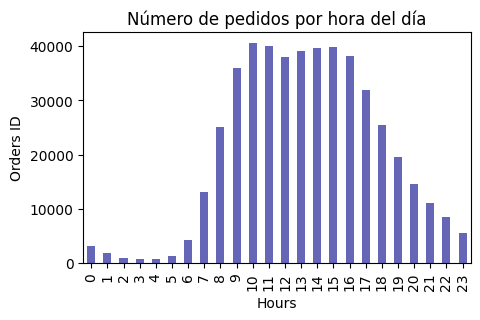

In [42]:
#pedidos por hora del día, #crear una variable:
orders_per_hour= df_orders['order_hour_of_day'].value_counts().sort_index()
orders_per_hour.plot(x='ordernes',
                     y='order_hour_of_day',
                     title='Número de pedidos por hora del día',
                     kind= 'bar',
                     xlabel= 'Hours',
                     ylabel= 'Orders ID',
                     color='darkblue',
                     alpha=(0.6),
                     figsize=(5,3)
)

plt.show()

Escribe aquí tus conclusiones

- El mayor numero de pedidos se encuentra entre las 10 am a las 4pm
- De la 1 am a 5 am el numero de pedidos es muy bajo
- Desde las 5 pm en adelnate la frecuencia de pedidos empieza a disminuir.

### [A3] ¿Qué día de la semana compran víveres las personas?

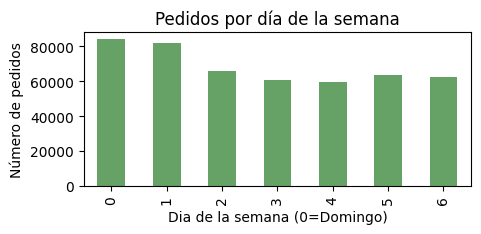

In [43]:
orders_per_day= df_orders['order_dow'].value_counts().sort_index()
orders_per_day.plot(kind='bar',
                    title= 'Pedidos por día de la semana',
                    xlabel= 'Dia de la semana (0=Domingo)',
                    ylabel= 'Número de pedidos',
                    color= 'darkgreen',
                    alpha=(0.6),
                    figsize=(5,2)
                   )

plt.show()

Escribe aquí tus conclusiones

- Los dias Domingo y lunes el número de pedidos es mayor.
- Los dias Jueves el numero de pedidos es menor.

 [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

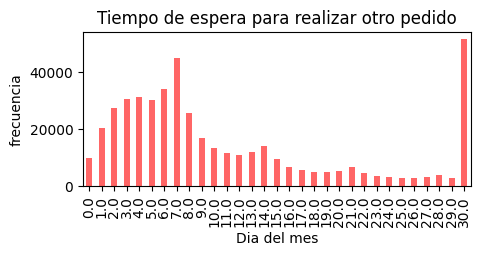

In [44]:
waiting_time= df_orders['days_since_prior_order'].value_counts().sort_index()
waiting_time.describe()
waiting_time.plot(kind='bar',
                  x='day',
                  y='frecuencia',
                  title= 'Tiempo de espera para realizar otro pedido',
                  xlabel= 'Dia del mes',
                  ylabel= 'frecuencia',
                 
 color= 'red',
                  alpha=(0.6),
                  figsize=(5,2)

                 )
plt.show()


Escribe aquí tus conclusiones

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [45]:
wednesday = df_orders.loc[df_orders['order_dow']==3]['order_hour_of_day'].value_counts().sort_index()
saturday = df_orders.loc[df_orders['order_dow']==6]['order_hour_of_day'].value_counts().sort_index()

In [46]:
wednesday_saturday = pd.concat([wednesday, saturday], axis=1)
wednesday_saturday.columns = ['wednesday', 'saturday']

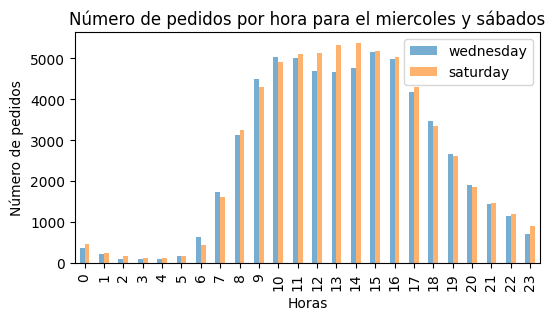

In [47]:
wednesday_saturday.plot(kind='bar',
                       title='Número de pedidos por hora para el miercoles y sábados',
                       xlabel='Horas',
                       ylabel= 'Número de pedidos',
                       alpha=(0.6),
                       figsize=(6,3)
)
plt.show()

Escribe aquí tus conclusiones

- A Las 15:00 del Miercoles hay mayor fecuencia de pedidos mientras que los Sabados la mayor freceuncia es a las 14:00.
- Desde las 17:00 en adelnate para los dos dias la frecuencia de pedidos empieza a disminuir
- desde la 00:00 a las 6:00 hay menor frecuencia de pedidos para ambos días

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [48]:
number_of_orders_per_customer = df_orders.groupby('user_id')['order_id'].count()
orders_distribution = number_of_orders_per_customer.value_counts().sort_index()


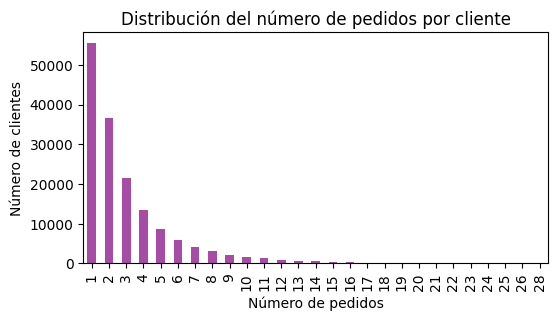

In [49]:
orders_distribution.plot(kind='bar',
                        title='Distribución del número de pedidos por cliente',
                        xlabel='Número de pedidos',
                        ylabel='Número de clientes',
                        color='purple',
                        alpha=0.7,
                        figsize=(6, 3))

plt.show()

Escribe aquí tus conclusiones

-55357 clientes hicieron solo 1 pedido.

-36508 clientes hicieron solo 2 pedidos.

-21547 clientes hicieron solo 3 pedidos. 

-Entre 25 a 20 pedidos son realizados por un cliente.

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [50]:
df_merge= df_order_products.merge(df_products,on='product_id')

In [51]:
top_20= df_merge.groupby(['product_id','product_name'])['order_id'].count().sort_values(ascending=False).head(20)

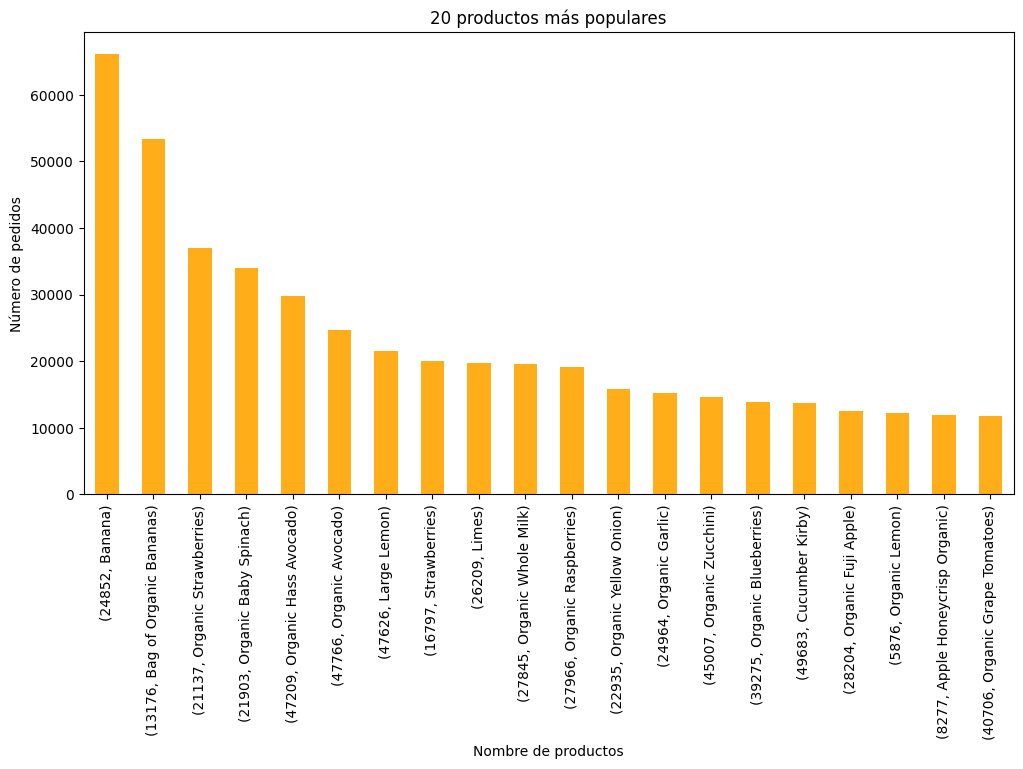

In [52]:
top_20.plot(kind='bar',
           title='20 productos más populares',
           xlabel='Nombre de productos',
           ylabel='Número de pedidos',
           color='orange',
           figsize=(12, 6),
           alpha=0.9
)

plt.show()

Escribe aquí tus conclusiones

-La mayoria de los 20 productos más populares son organicos.

-El producto que mas se ordena son las bananas.




# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [53]:
products_per_order= df_order_products.groupby('order_id')['product_id'].count()

In [54]:
products_distribution = products_per_order.value_counts().sort_index()

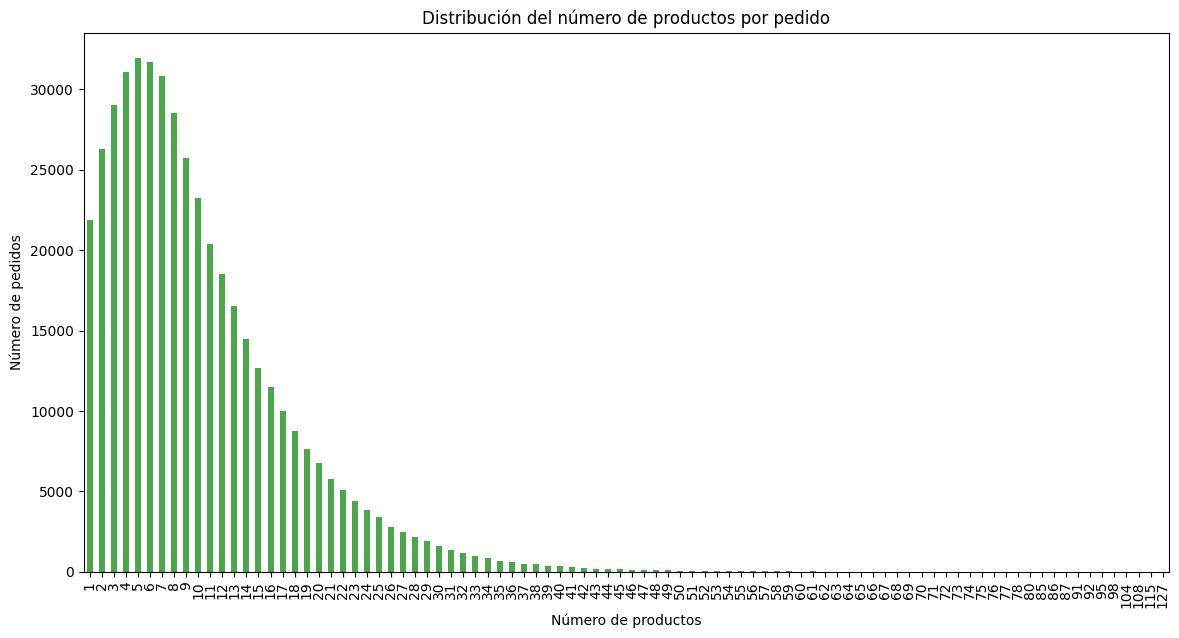

In [55]:
products_distribution.plot(kind='bar',
                          title='Distribución del número de productos por pedido',
                          xlabel='Número de productos',
                          ylabel='Número de pedidos',
                          color='green',
                          alpha=0.7,
                          figsize=(14,7))

plt.show()

Escribe aquí tus conclusiones

- la mayoría de las personas realizaron de 1 a 5 pedidos.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [56]:
products_reordered= df_order_products[df_order_products['reordered']==1]

In [57]:
products_reordered_name= products_reordered.merge(df_products[['product_id', 'product_name']], on='product_id')

In [58]:
top_20_items= products_reordered_name.groupby(['product_id','product_name'])['product_id'].count().sort_values(ascending=False).head(20)

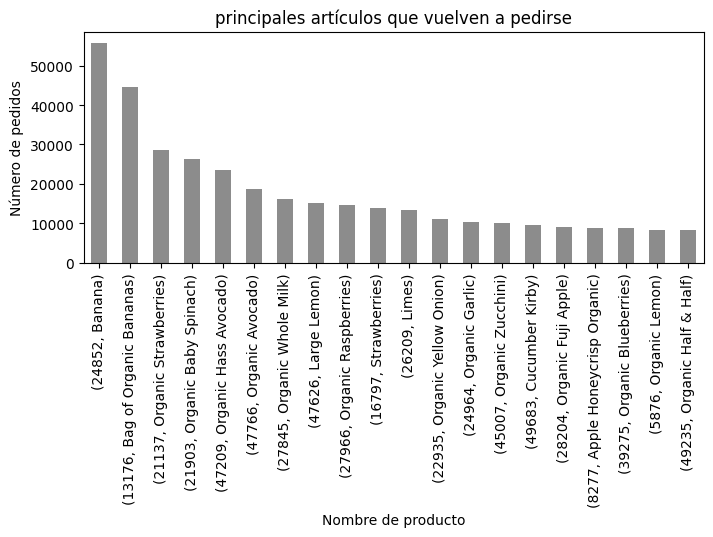

In [59]:
top_20_items.plot(kind='bar',
                 title='principales artículos que vuelven a pedirse',
                 xlabel='Nombre de producto',
                 ylabel='Número de pedidos',
                 color='grey',
                 figsize=(8, 3),
                 alpha=0.9
                 )
                      
plt.show()

Escribe aquí tus conclusiones
- los 20 principales artículos que vuelven a pedirse con mayor frecuencia son las babanas y los productos organicos como las fresas, las espinacas baby, aguacate hass entre otros productos organicos.

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [60]:
reordered_products= df_products.merge(df_order_products,on='product_id')

In [61]:
proportion= reordered_products.groupby(['product_id','product_name'])['reordered'].mean().reset_index()
display(proportion)

,product_id,product_name,reordered
0,1,Chocolate Sandwich Cookies,0.564286
1,2,All-Seasons Salt,0.000000
2,3,Robust Golden Unsweetened Oolong Tea,0.738095
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,0.510204
4,7,Pure Coconut Water With Orange,0.500000
...,...,...,...
45568,49690,HIGH PERFORMANCE ENERGY DRINK,0.800000
45569,49691,ORIGINAL PANCAKE & WAFFLE MIX,0.430556
45570,49692,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,0.416667
45571,49693,SPRING WATER BODY WASH,0.440000


Escribe aquí tus conclusiones

-Los Chocolate Sandwich Cookies se volvieron a ordernar en un 56%.

-El BURRITO- STEAK & CHEESE se volvio a ordenar en un 33%.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [62]:
order_id_proportion= df_orders.merge(df_order_products,on='order_id')


In [63]:
order_id_proportion.groupby(['user_id'])['reordered'].mean().reset_index()


,user_id,reordered
0,2,0.038462
1,4,0.000000
2,5,0.666667
3,6,0.000000
4,7,0.928571
...,...,...
149621,206203,0.222222
149622,206206,0.714286
149623,206207,0.891304
149624,206208,0.696000


Escribe aquí tus conclusiones

-EL user_id 7 volvio a realizar una orden en un 93%.

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [64]:
top_20_added_to_the_cart= df_order_products[df_order_products['add_to_cart_order']==1]
top_20_added_to_the_cart= top_20_added_to_the_cart.merge(df_products, on ='product_id') 


In [65]:
top_20_added_to_the_cart.groupby(['product_id','product_name'])['product_id']\
    .count()\
    .sort_values(ascending=False)\
    .reset_index(name='order_count')\
    .head(20)

,product_id,product_name,order_count
0,24852,Banana,15562
1,13176,Bag of Organic Bananas,11026
2,27845,Organic Whole Milk,4363
3,21137,Organic Strawberries,3946
4,47209,Organic Hass Avocado,3390
5,21903,Organic Baby Spinach,3336
6,47766,Organic Avocado,3044
7,19660,Spring Water,2336
8,16797,Strawberries,2308
9,27966,Organic Raspberries,2024


Escribe aquí tus conclusiones


- En el top 3 las ordenes que mas se vuelven a ordernar son: los bananos ,  la bolsa organica de bananos y la leche entera orgánica
- La cebolla amarilla orgánica se vuleven a ordernar  hasta 1246 veces.

### Conclusion general del proyecto:


- **Paso 1:** se abrieron los archivos(/datasets/instacart_orders.csv, /datasets/products.csv, /datasets/aisles.csv, /datasets/departments.csv y /datasets/order_products.csv) para ver el contenido general de la tabla. se establecieron ciertos criterios como pd.read_csv() para leer los datos correctamente.
- **Paso 2**: se verifico y se corrigieron los tipos de datos, se identificaron los valores ausentes como tambien se eliminaron los valores duplicados usando el método correspondiente para esta parte del proyecto.

- **Paso 3**: una vez se procesaron los datos y los dejamos listo para el respectivo análisis, notamos que el comportamiento de los clientes al realizar sus pedidos era que el producto más pedido eran los bananos, seguidos de productos organicos como las fresas, las espinacas baby el agucate hass entros productos organicos.
